In [1]:
from src.utils import get_data_env
from src.UPDATED_dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager
from src.UPDATED_models import PersistenceModel, NodeRFModel

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 4
horizon_leadtime= 1
sequence_length = 1
lags            = 4

config = EpiConfig(
    disease             = 'measles',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lags                = lags,
    nuts_level          = nuts_level,
    log_transform       = True,
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest
    )    

data_orchestrator = DataOrchestrator(config).build()
shallowdata       = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
deepdata          = GraphDataLoaderManager(data_orchestrator).retrieve_graph('identity_graph').construct_dataloaders()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# DeepDataLoader previewer
node_idx = 26

data        = deepdata.dataloader_collection.test
node_data   = []

for tt in range(len(data)):
    node_data.append(data[tt].x[node_idx][2])



Text(0.5, 1.0, 'Measles incidence in Hamburg')

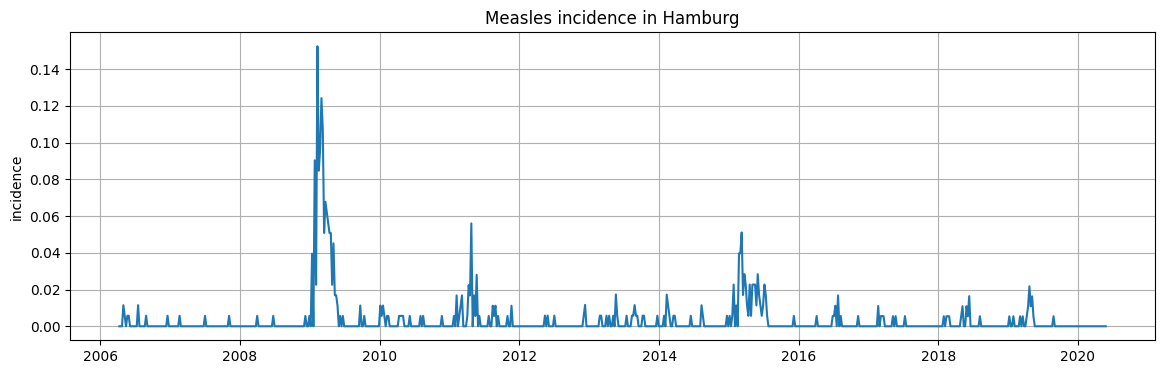

In [16]:
fig, ax = plt.subplots(1,1, figsize = (14,4))

data = data_orchestrator.data_processed.epidata

sns.lineplot(data[data['node'] == 15], x = 'timestamp', y='incidence')
ax.grid()
ax.set_xlabel("")
ax.set_title("Measles incidence in Hamburg")

Text(0.5, 1.0, 'Input - Target\nhorizon_leadtime: 2')

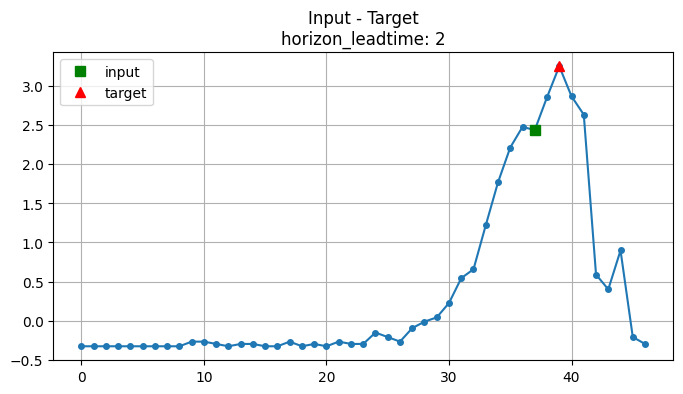

In [77]:
L = 2
h = 1
tt = 37

fig, ax = plt.subplots(1,1, figsize = (8,4))
ax.grid()
ax.plot(node_data, '-o', markersize=4)
ax.plot([tt], [node_data[tt]], 's', markersize=7.5, color='green', label = 'input')
ax.plot([tt+L], [node_data[tt+L]], '^', markersize=7.5, color='red', label = 'target')
ax.legend()
ax.set_title(f'Input - Target\nhorizon_leadtime: {L}')


MovieWriter imagemagick unavailable; using Pillow instead.


Frame: 0, len(node_data): 100


IndexError: list index out of range

Frame: 0, len(node_data): 100
Error in callback <function _draw_all_if_interactive at 0x7f59f48ea980> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: x must be a sequence

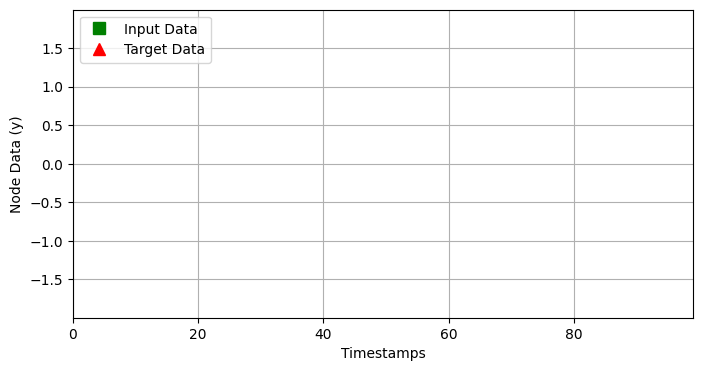

In [37]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Example node_data (replace this with your actual data)
node_data = np.sin(np.linspace(0, 10, 100))  # Example: Sinusoidal path for y-values

# Parameters for the input (green square) and target (red triangle)
d = 1  # The fixed distance between green and red marker

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 4))
ax.grid()

# Create the plot elements for the green square and red triangle
green_marker, = ax.plot([], [], 'gs', label='Input Data', markersize=8)  # 'gs' is the color/shape for green square
red_marker, = ax.plot([], [], 'r^', label='Target Data', markersize=8)   # 'r^' is the color/shape for red triangle

# Set limits and labels for the plot
ax.set_xlim(0, len(node_data) - 1)  # x-axis will range from 0 to len(node_data)-1
ax.set_ylim(min(node_data) - 1, max(node_data) + 1)  # y-axis based on the min/max of node_data
ax.set_xlabel('Timestamps')
ax.set_ylabel('Node Data (y)')
ax.legend(loc='upper left')

# Update function for the animation
def update_frame(frame):
    # Debugging: Print the current frame and the length of node_data
    print(f"Frame: {frame}, len(node_data): {len(node_data)}")
    
    if frame >= len(node_data):  # Ensure the frame index is within bounds
        print("Warning: Frame index out of range!")
        return green_marker, red_marker

    # Green square position: Move along x and y from node_data
    green_x = frame
    green_y = node_data[frame]  # y-position comes from node_data
    
    # Red triangle position: Maintain fixed distance d along x-axis
    red_x = green_x + d
    red_y = node_data[frame]  # y-position is the same as the green square (you can change this if needed)
    
    # Update the markers with the new positions
    green_marker.set_data(green_x, green_y)
    red_marker.set_data(red_x, red_y)
    
    return green_marker, red_marker

# Create the animation with explicit frame indexing
ani = animation.FuncAnimation(
    fig,
    update_frame,
    frames=len(node_data),  # Ensure that frames corresponds to the length of node_data
    interval=100
)

# Save the animation as a GIF
ani.save('animated_plot.gif', writer='imagemagick', fps=10)

plt.show()


(<Figure size 1600x1200 with 2 Axes>,
 array([<Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>,
        <Axes: title={'center': 'LK Diepholz [node: 27]'}, ylabel='target'>],
       dtype=object))

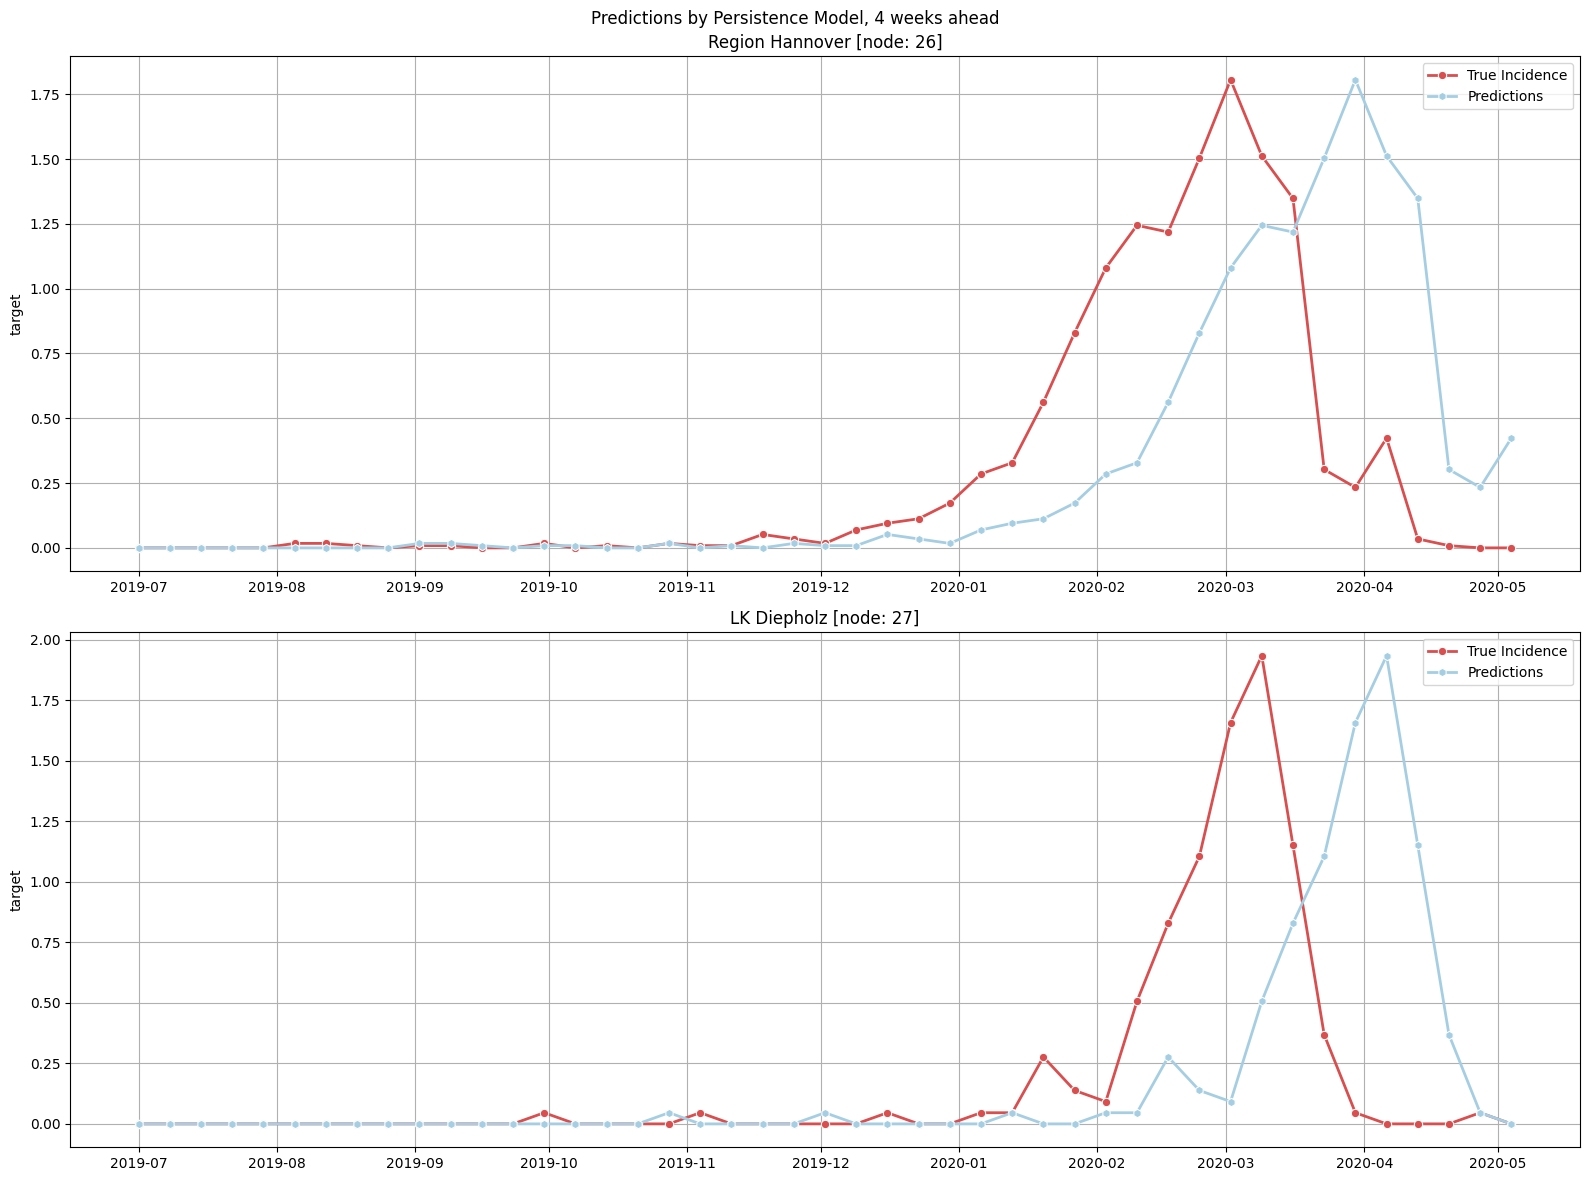

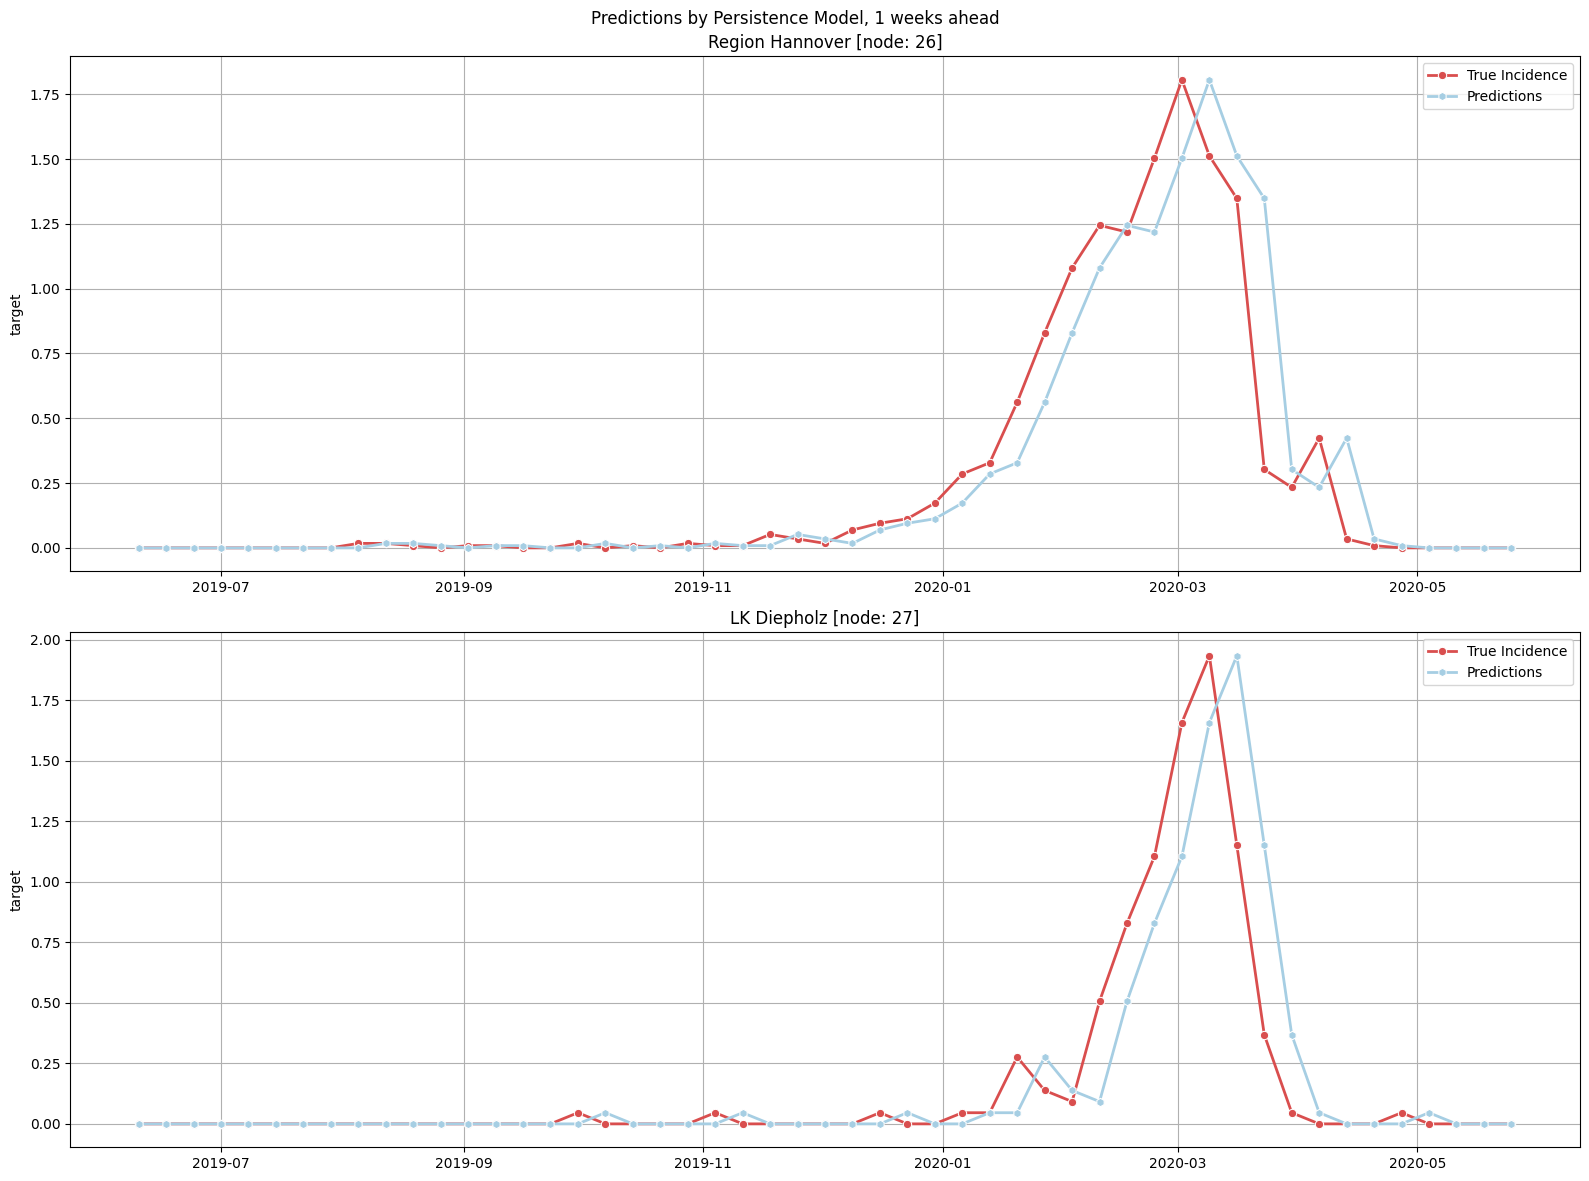

In [2]:
persistence = PersistenceModel(shallowdata)
persistence.forecast('test')
persistence.show_forecasts([26,27], horizon=3,  transformed=False)
persistence.show_forecasts([26,27], horizon=0,  transformed=False)


In [3]:
rf = NodeRFModel(shallowdata)
rf.set_global_hparams()
rf.set_model_hparams(n_estimators=1)
rf.train(verbose=0)
rf.forecast('test')
rf.forecast('train')
rf.forecast('val')    


NodeRFModel(name='NodeRFModel')

(<Figure size 1600x1700 with 3 Axes>,
 array([<Axes: title={'center': 'SK Hamburg [node: 15]'}, ylabel='target'>,
        <Axes: title={'center': 'Region Hannover [node: 26]'}, ylabel='target'>,
        <Axes: title={'center': 'SK München [node: 223]'}, ylabel='target'>],
       dtype=object))

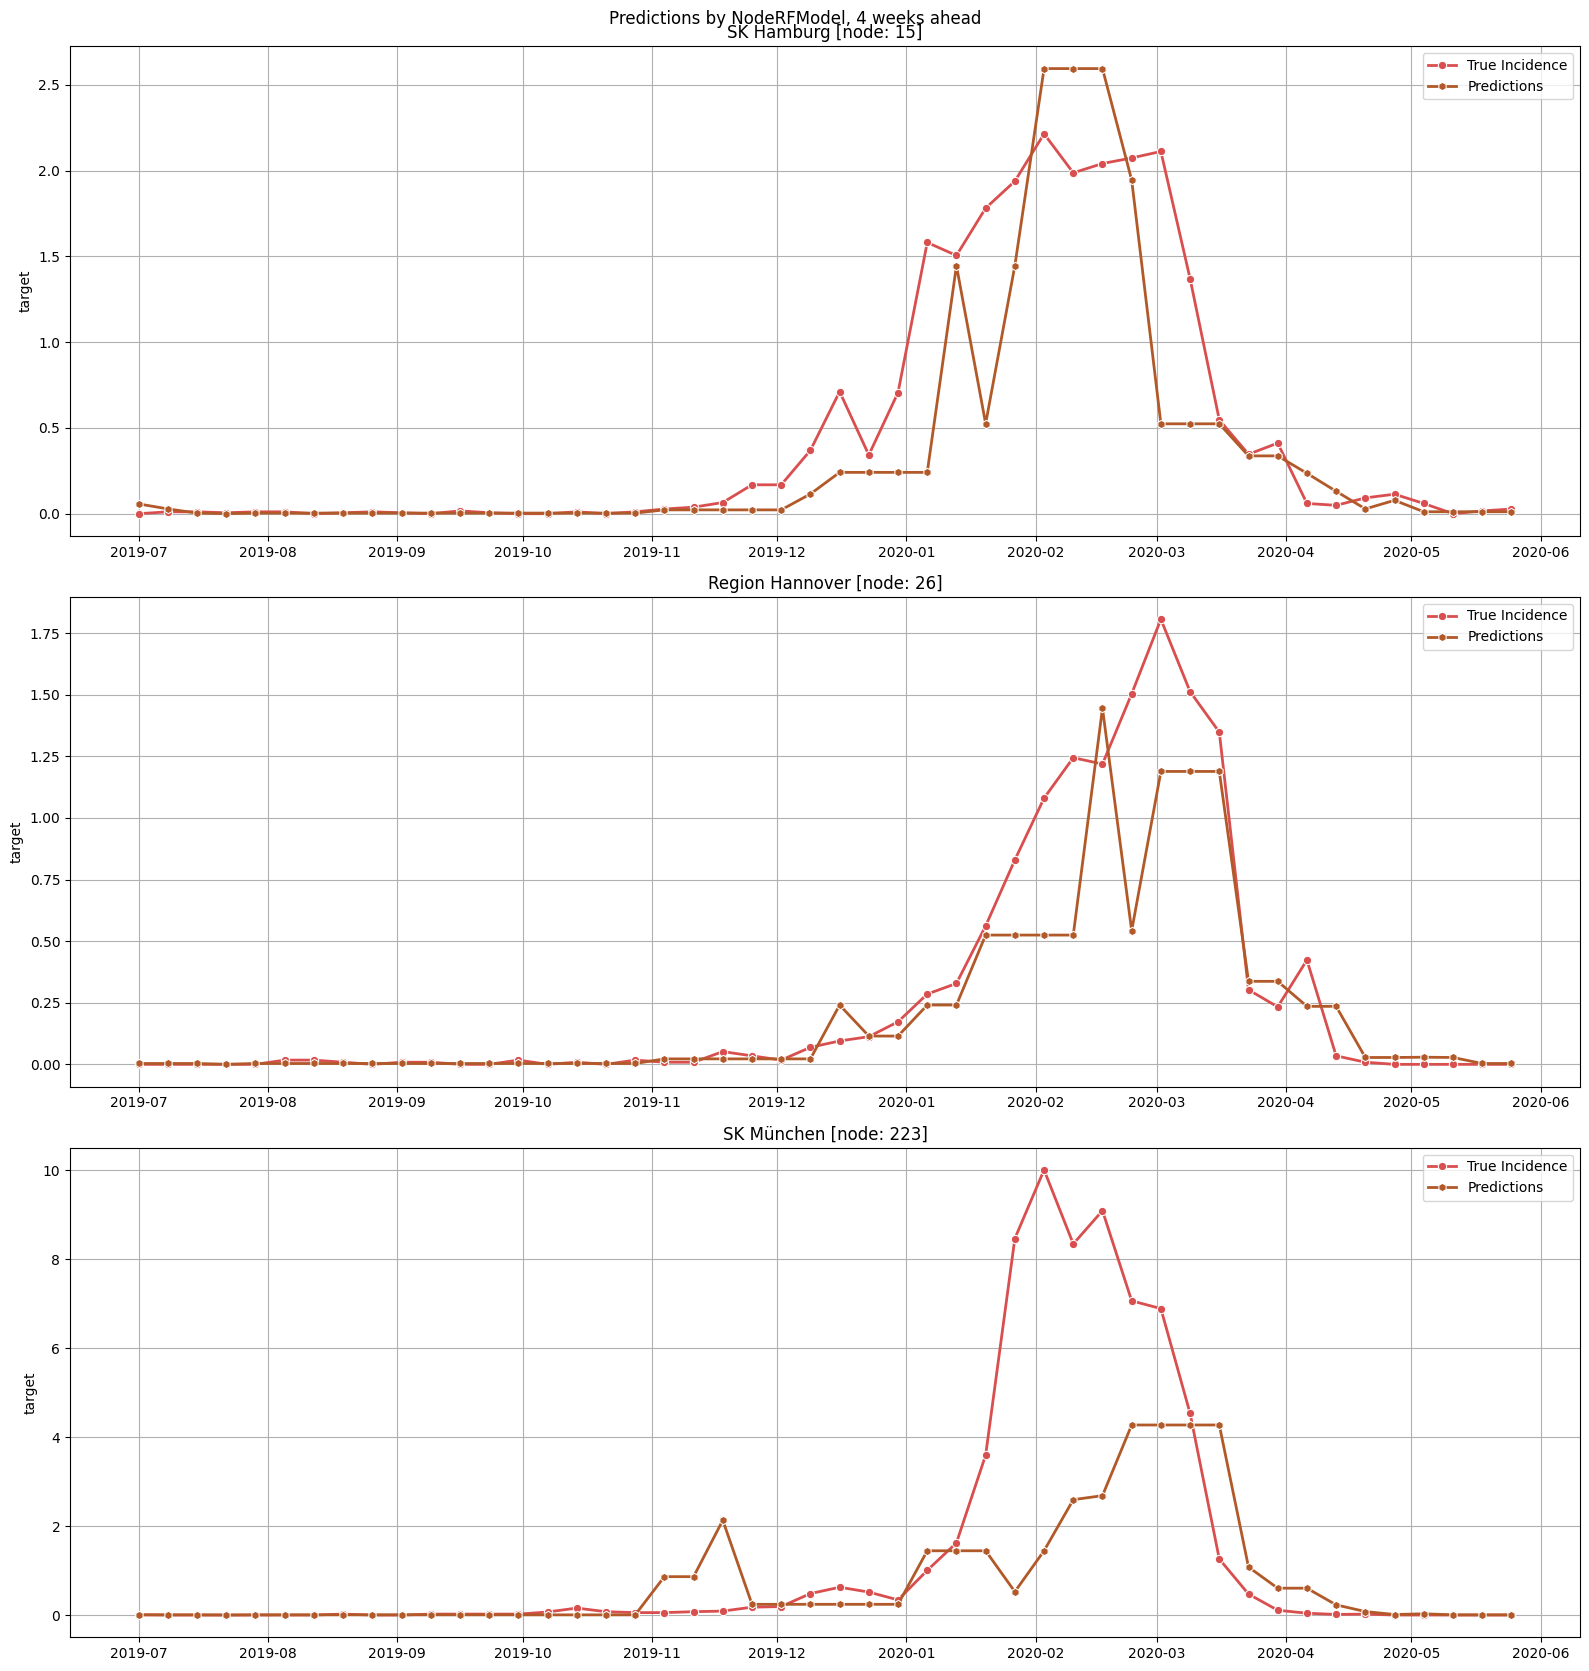

In [4]:
# rf.show_forecasts(26, horizon=3,  transformed=False)
rf.show_forecasts([15,26,223], horizon=3, transformed=False)

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.03it/s]
/home/de-schrijvers/projects/germany_gnn/src/UPDATED_evaluation/evaluationplotter.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


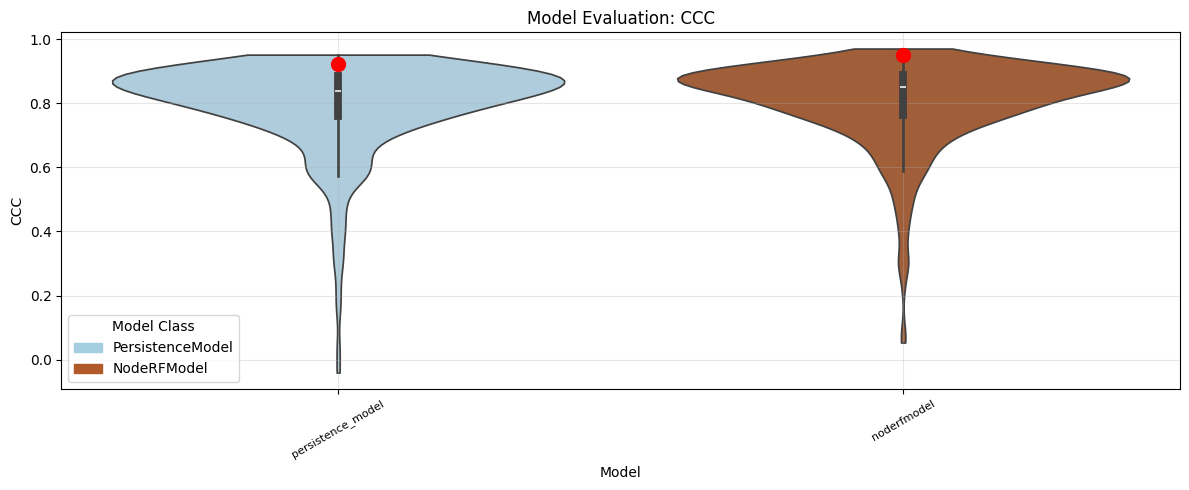

In [ ]:
from src.UPDATED_evaluation.evaluator import Evaluator
evaluation = Evaluator([persistence,rf])

evaluation.add_evaluation(0, 'test')
evaluation.add_evaluation(1, 'test')

evaluation.plotter.plot_metric('ccc', 'horizon_0', 'test', 'violin', 26)